In [334]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import xgboost as xgb

from sklearn.linear_model import LogisticRegression


In [335]:
df = pd.read_csv('../asteroids_2025_flat.csv')

In [336]:
df.head()

,close_approach_date,id,neo_reference_id,name,designation,nasa_jpl_url,absolute_magnitude_h,estimated_diameter_min_km,estimated_diameter_max_km,estimated_diameter_min_m,...,perihelion_distance,perihelion_argument,aphelion_distance,perihelion_time,mean_anomaly,mean_motion,equinox,orbit_class_type,orbit_class_description,orbit_class_range
0,2025-01-07,2226514,2226514,226514 (2003 UX34),NaN,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,20.16,0.246919,0.552128,246.919266,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-07,2438017,2438017,438017 (2003 YO3),NaN,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,18.54,0.520661,1.164233,520.660914,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-07,2481442,2481442,481442 (2006 WO3),NaN,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,21.58,0.128397,0.287104,128.397030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-07,3485806,3485806,(2010 AL60),NaN,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,22.29,0.092588,0.207033,92.588058,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-07,3723888,3723888,(2015 NU2),NaN,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,20.91,0.174805,0.390877,174.805453,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [337]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6101 entries, 0 to 6100
Data columns (total 52 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   close_approach_date                6101 non-null   object 
 1   id                                 6101 non-null   int64  
 2   neo_reference_id                   6101 non-null   int64  
 3   name                               6101 non-null   object 
 4   designation                        0 non-null      float64
 5   nasa_jpl_url                       6101 non-null   object 
 6   absolute_magnitude_h               6101 non-null   float64
 7   estimated_diameter_min_km          6101 non-null   float64
 8   estimated_diameter_max_km          6101 non-null   float64
 9   estimated_diameter_min_m           6101 non-null   float64
 10  estimated_diameter_max_m           6101 non-null   float64
 11  estimated_diameter_min_miles       6101 non-null   float

In [338]:
df.drop(columns=["nasa_jpl_url", "designation", "id", "neo_reference_id", "name", "orbiting_body", "close_approach_date_full", "close_approach_date"], inplace=True)


In [339]:
# Check null percentages for ALL variables
null_percentages = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(null_percentages)

ascending_node_longitude             100.0
orbital_period                       100.0
perihelion_distance                  100.0
jupiter_tisserand_invariant          100.0
orbit_determination_date             100.0
first_observation_date               100.0
last_observation_date                100.0
data_arc_in_days                     100.0
observations_used                    100.0
orbit_uncertainty                    100.0
minimum_orbit_intersection           100.0
orbit_id                             100.0
aphelion_distance                    100.0
perihelion_time                      100.0
mean_anomaly                         100.0
mean_motion                          100.0
equinox                              100.0
orbit_class_type                     100.0
orbit_class_description              100.0
perihelion_argument                  100.0
orbit_class_range                    100.0
semi_major_axis                      100.0
eccentricity                         100.0
epoch_oscul

In [340]:
df.drop(columns=["estimated_diameter_min_m", "estimated_diameter_max_m", "estimated_diameter_min_miles", "estimated_diameter_max_miles", "estimated_diameter_min_feet", "estimated_diameter_max_feet", "relative_velocity_km_per_hour", "relative_velocity_miles_per_hour", "miss_distance_astronomical", "miss_distance_lunar", "miss_distance_miles"], inplace=True)

In [341]:
df.dropna(axis=1, inplace=True)

In [342]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6101 entries, 0 to 6100
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   absolute_magnitude_h               6101 non-null   float64
 1   estimated_diameter_min_km          6101 non-null   float64
 2   estimated_diameter_max_km          6101 non-null   float64
 3   is_potentially_hazardous_asteroid  6101 non-null   bool   
 4   is_sentry_object                   6101 non-null   bool   
 5   epoch_date_close_approach          6101 non-null   int64  
 6   relative_velocity_km_per_sec       6101 non-null   float64
 7   miss_distance_kilometers           6101 non-null   float64
dtypes: bool(2), float64(5), int64(1)
memory usage: 298.0 KB


In [343]:
df.head()

,absolute_magnitude_h,estimated_diameter_min_km,estimated_diameter_max_km,is_potentially_hazardous_asteroid,is_sentry_object,epoch_date_close_approach,relative_velocity_km_per_sec,miss_distance_kilometers
0,20.16,0.246919,0.552128,True,False,1736208480000,16.548994,1.849152e+07
1,18.54,0.520661,1.164233,False,False,1736238240000,15.276752,1.213633e+07
2,21.58,0.128397,0.287104,False,False,1736238060000,21.648876,5.823974e+07
3,22.29,0.092588,0.207033,False,False,1736236080000,8.989291,9.414482e+06
4,20.91,0.174805,0.390877,True,False,1736290080000,19.133631,7.346700e+07


In [344]:
df.shape

(6101, 8)

In [345]:
df.to_csv("asteroids_cleaned.csv", index=False)


In [346]:
df = pd.read_csv('asteroids_cleaned.csv')

## **Visuals**

In [347]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Times New Roman'],
    'font.size': 12,              
    'axes.titlesize': 20,       
    'axes.labelsize': 14,  
    'axes.labelcolor': 'darkgrey',      
})

In [348]:
df['miss_distance_kilometers'].describe()

count    6.101000e+03
mean     2.517659e+07
std      2.254705e+07
min      6.599181e+03
25%      5.632062e+06
50%      1.827075e+07
75%      4.199399e+07
max      7.478989e+07
Name: miss_distance_kilometers, dtype: float64

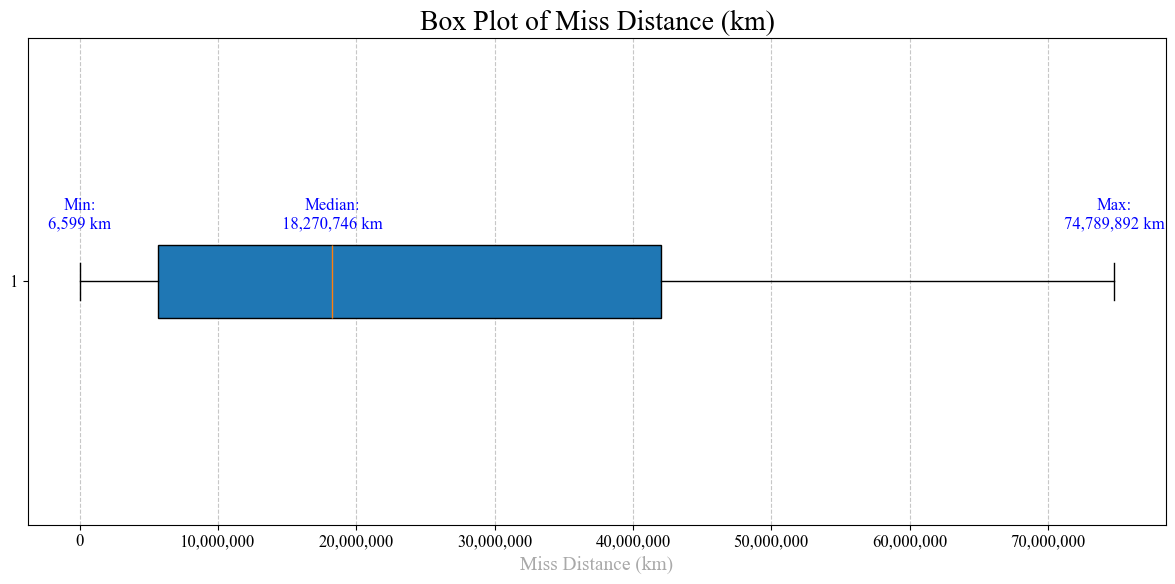

In [349]:
from matplotlib import ticker


plt.figure(figsize=(12, 6))
miss_bp = plt.boxplot(df['miss_distance_kilometers'], vert=False, patch_artist=True, whis=[0, 100])
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Box Plot of Miss Distance (kilometers)')
plt.xlabel('Miss distance (km)', rotation=0)

stats = df['miss_distance_kilometers'].describe()
vals_to_annotate = {
    'Min': stats['min'],
    'Median': stats['50%'],
    'Max': stats['max'],
}

for label, val in vals_to_annotate.items():
    plt.text(val, 1.1, f'{label}:\n{val:,.0f} km', 
             ha='center', va='bottom', color='blue')

plt.title('Box Plot of Miss Distance (km)')
plt.xlabel('Miss Distance (km)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()



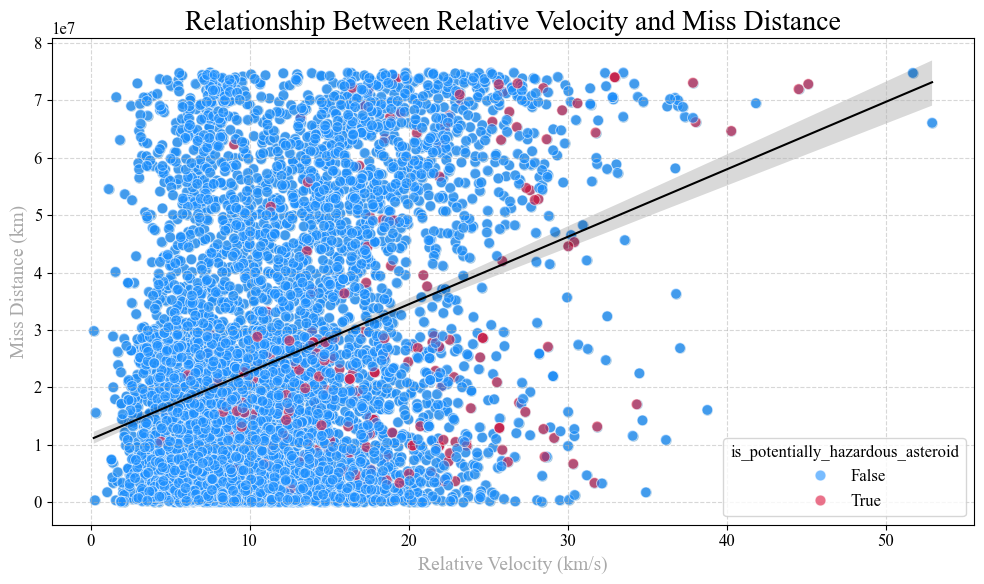

In [350]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='relative_velocity_km_per_sec',
    y='miss_distance_kilometers',
    alpha=0.6,
    edgecolor='w',
    s=60
)

sns.scatterplot(
    data=df,
    x='relative_velocity_km_per_sec',
    y='miss_distance_kilometers',
    hue='is_potentially_hazardous_asteroid',
    palette={False: 'dodgerblue', True: 'crimson'},
    alpha=0.6,
    edgecolor='w',
    s=60,
    legend='brief'
)

sns.regplot(
    data=df,
    x='relative_velocity_km_per_sec',
    y='miss_distance_kilometers',
    scatter=False,
    color='black',
    line_kws={'linewidth': 1.5}
)

plt.title('Relationship Between Relative Velocity and Miss Distance')
plt.xlabel('Relative Velocity (km/s)')
plt.ylabel('Miss Distance (km)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

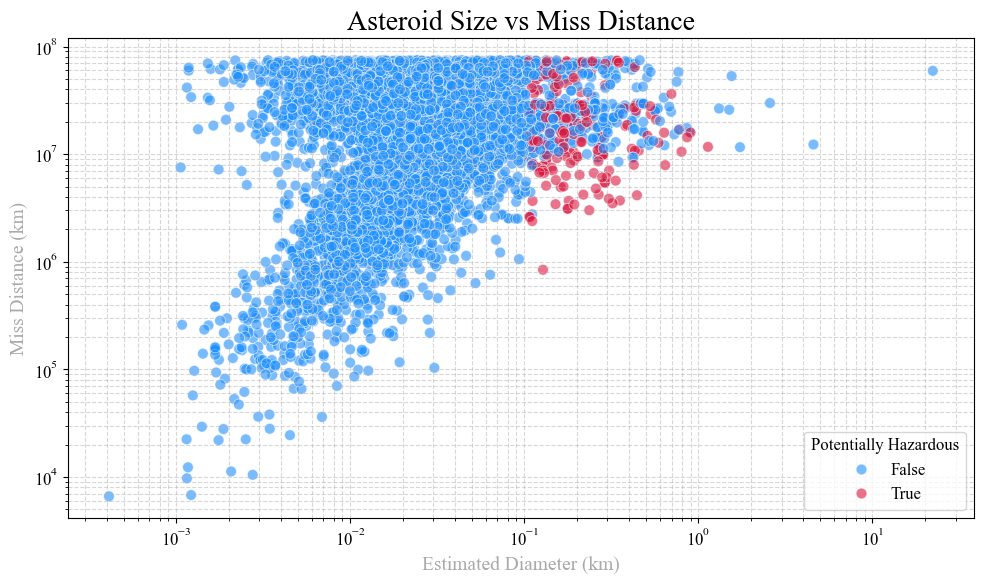

In [351]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x= df['estimated_diameter_min_km'],
    y=df['miss_distance_kilometers'],
    hue=df['is_potentially_hazardous_asteroid'],
    palette={False: 'dodgerblue', True: 'crimson'},
    alpha=0.6,
    edgecolor='w',
    s=60
)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Estimated Diameter (km)')
plt.ylabel('Miss Distance (km)')
plt.title('Asteroid Size vs Miss Distance')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(title='Potentially Hazardous', loc='lower right')
plt.tight_layout()
plt.show()

## **getting data ready for training**
### predictor value = potentially_hazardous_asteroid

In [352]:
X = df.drop(columns=["is_potentially_hazardous_asteroid"])
y = df['is_potentially_hazardous_asteroid']

In [353]:
X['is_sentry_object'] = X['is_sentry_object'].astype(int)

In [354]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [355]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Logistic Regression**

In [356]:
model = LogisticRegression(solver='liblinear')
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [361]:
model.score(X_test_scaled, y_test)

0.9656019656019657